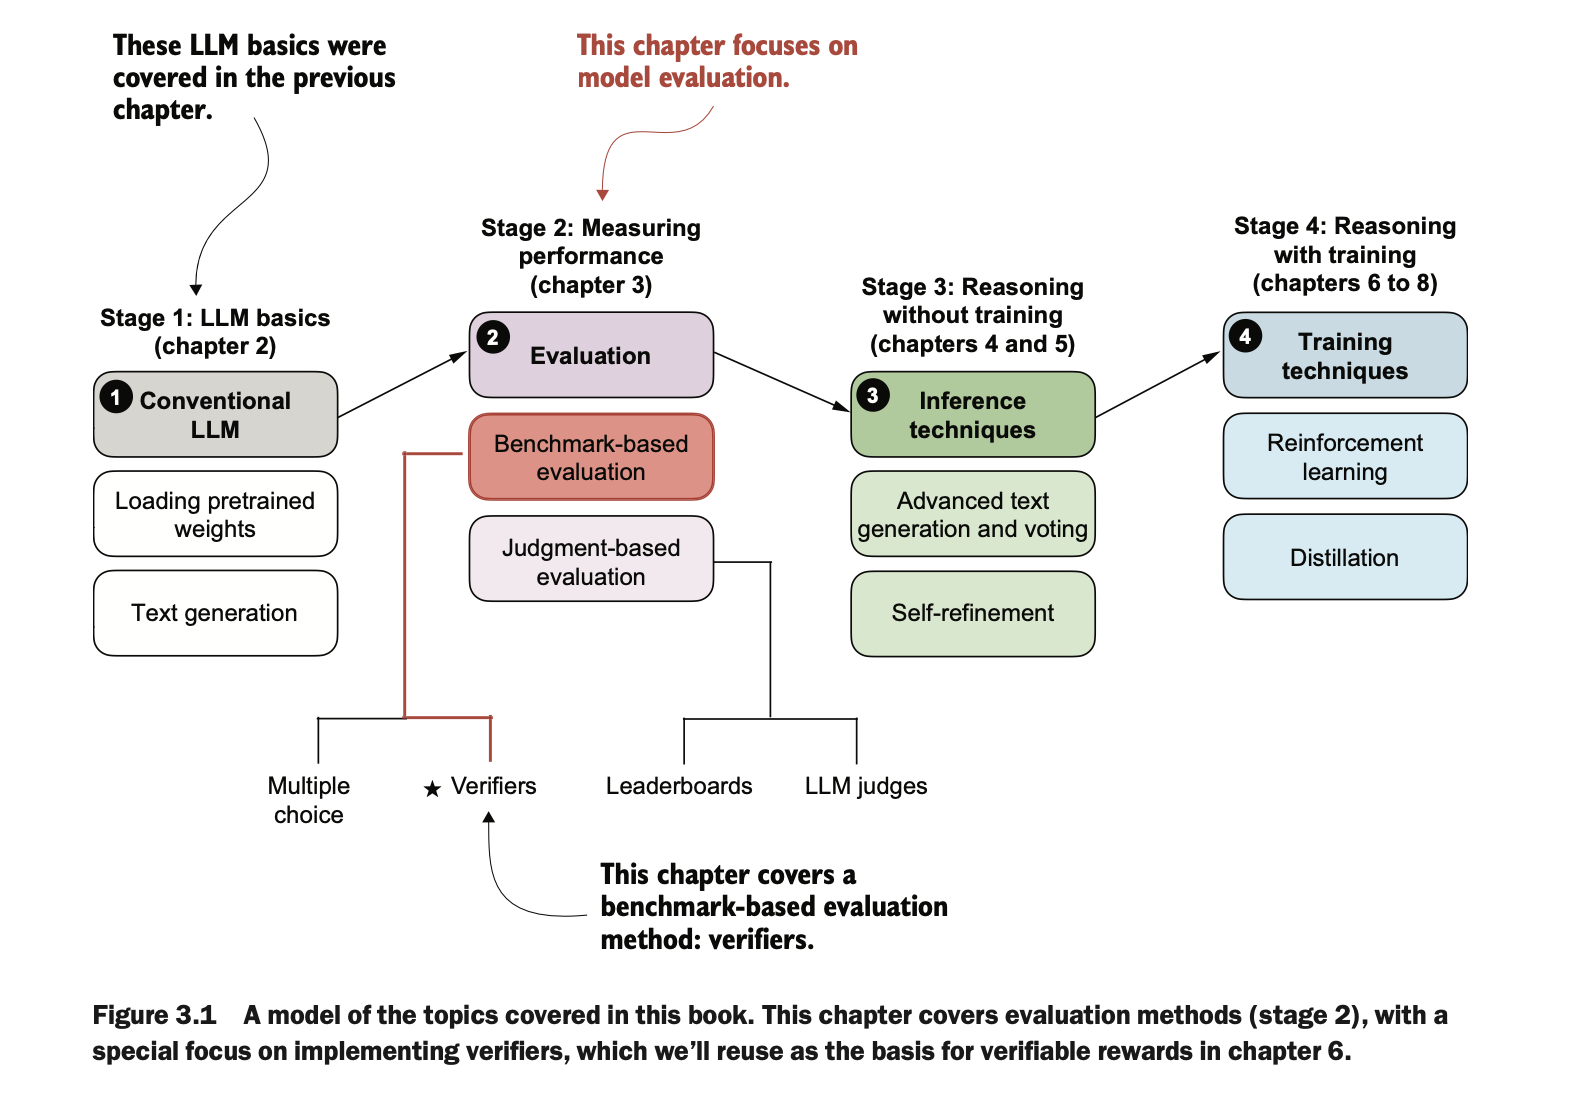


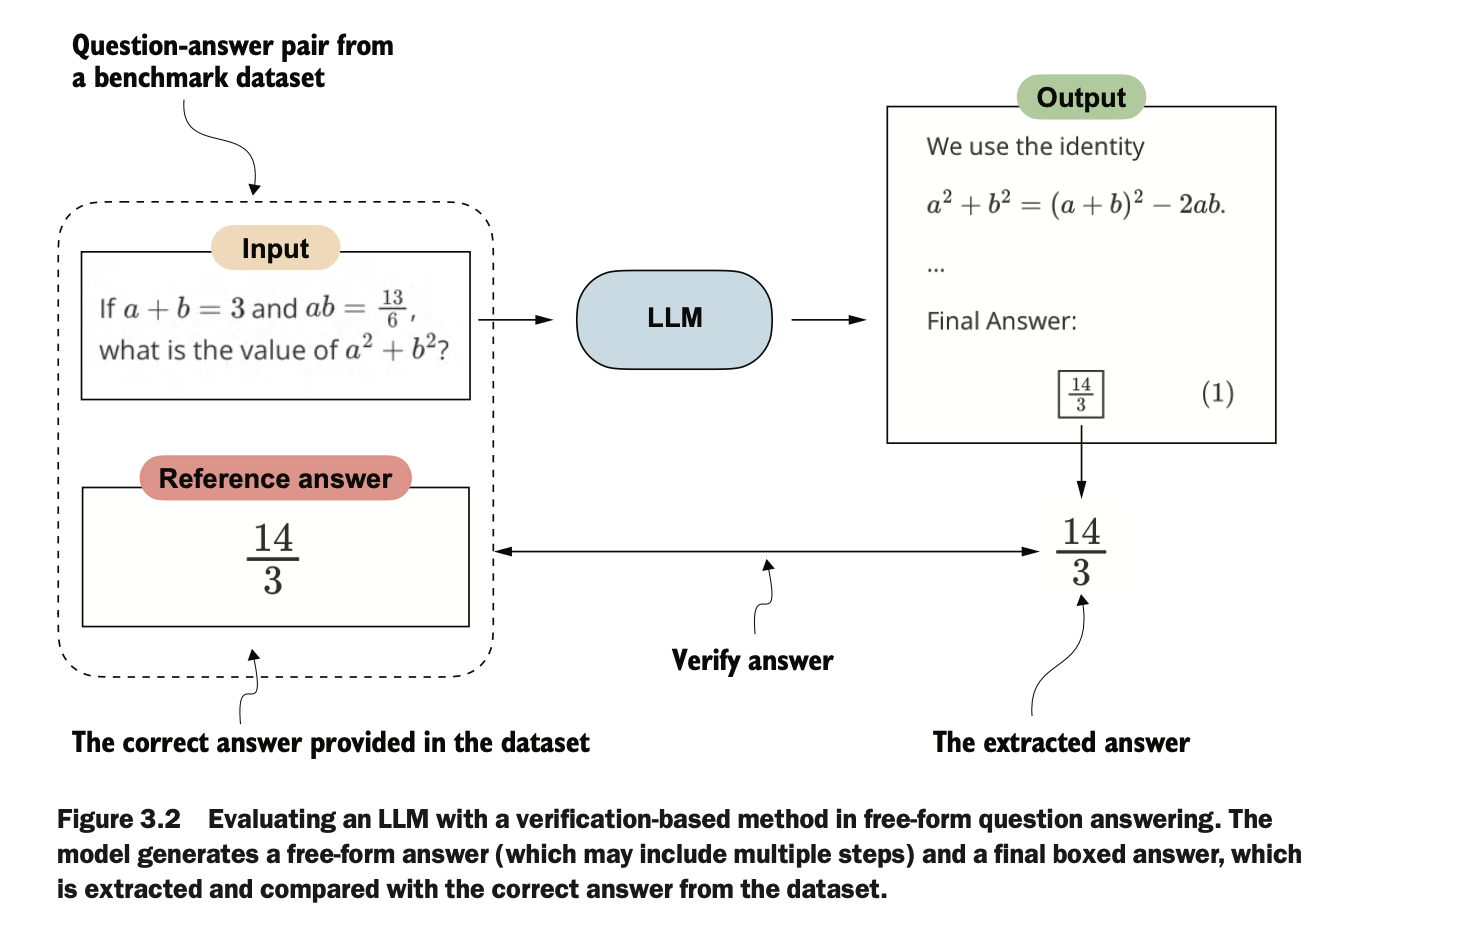


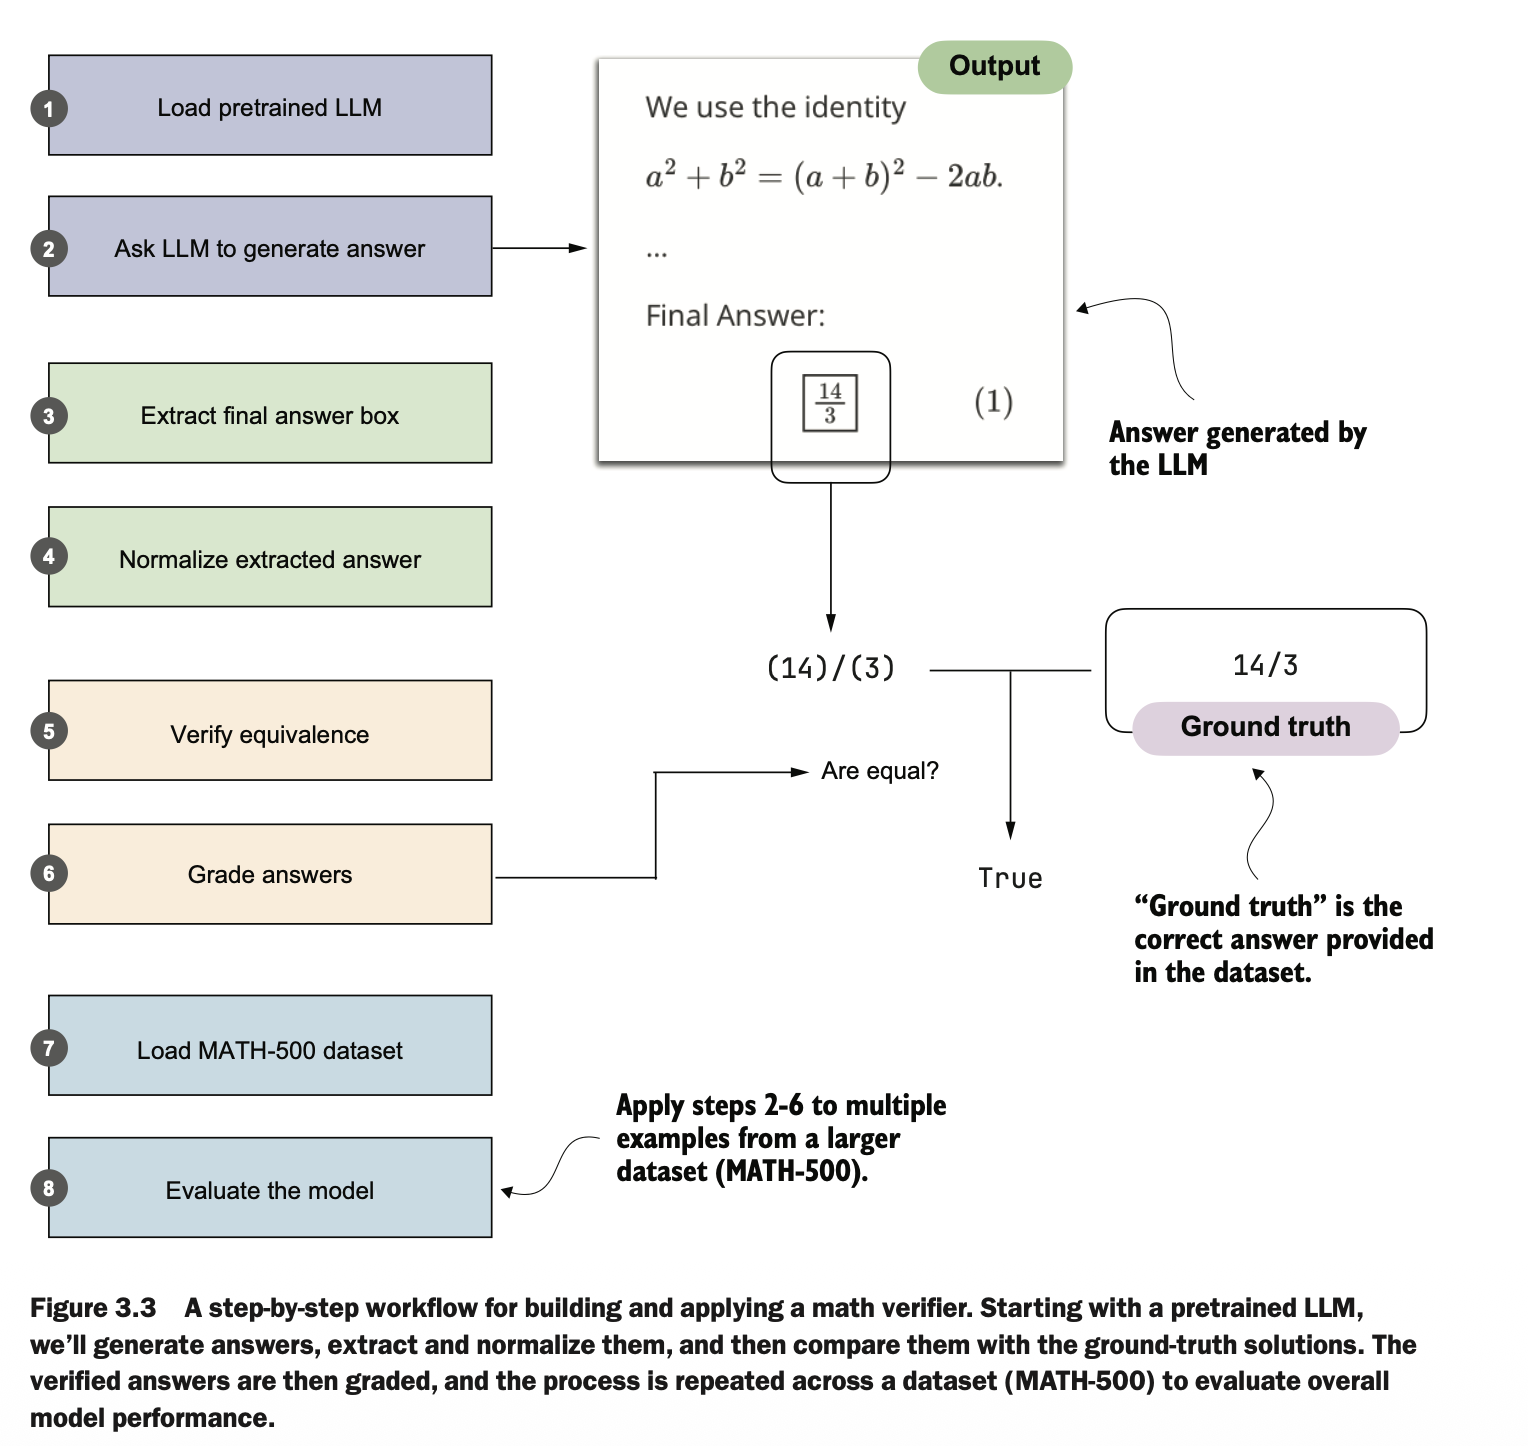


In [1]:
from pathlib import Path
import torch


from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer,
    Qwen3Model,
    QWEN_CONFIG_06_B,
)


def load_model_and_tokenizer(which_model, device, use_compile, local_dir="qwen3"):
    if which_model == "base":

        download_qwen3_small(kind="base", tokenizer_only=False, out_dir=local_dir)

        tokenizer_path = Path(local_dir) / "tokenizer-base.json"
        model_path = Path(local_dir) / "qwen3-0.6B-base.pth"
        tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

    elif which_model == "reasoning":

        download_qwen3_small(kind="reasoning", tokenizer_only=False, out_dir=local_dir)

        tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
        model_path = Path(local_dir) / "qwen3-0.6B-reasoning.pth"
        tokenizer = Qwen3Tokenizer(
            tokenizer_file_path=tokenizer_path,
            apply_chat_template=True,
            add_generation_prompt=True,
            add_thinking=True,
        )

    else:
        raise ValueError(f"Invalid choice: which_model={which_model}")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(torch.load(model_path))

    model.to(device)

    if use_compile:
        torch._dynamo.config.allow_unspec_int_on_nn_module = True
        model = torch.compile(model)

    return model, tokenizer

In [3]:
from reasoning_from_scratch.ch02 import get_device

WHICH_MODEL = "base"
device = get_device()

# If you have compatibility issues, try to
# uncomment the line below and rerun the notebook
# device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model=WHICH_MODEL, device=device, use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [8]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache

prompt = r"If $a+b=3$ and $ab=\tfrac{13}{6}$, " r"what is the value of $a^2+b^2$?"

# Similar to chapter 2 exercise solution:
input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt), device=device
).unsqueeze(0)

all_token_ids = []
for token in generate_text_basic_stream_cache(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=2048,
    eos_token_id=tokenizer.eos_token_id,
):
    token_id = token.squeeze(0)
    decoded_id = tokenizer.decode(token_id.tolist())
    print(decoded_id, end="", flush=True)
    all_token_ids.append(token_id)

all_tokens = tokenizer.decode(all_token_ids)

 To find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [10]:
# render the latex text in a more readable format
from IPython.display import Latex, display

display(Latex(all_tokens))

<IPython.core.display.Latex object>

# 3.3 Implementing a wrapper for easier text generation

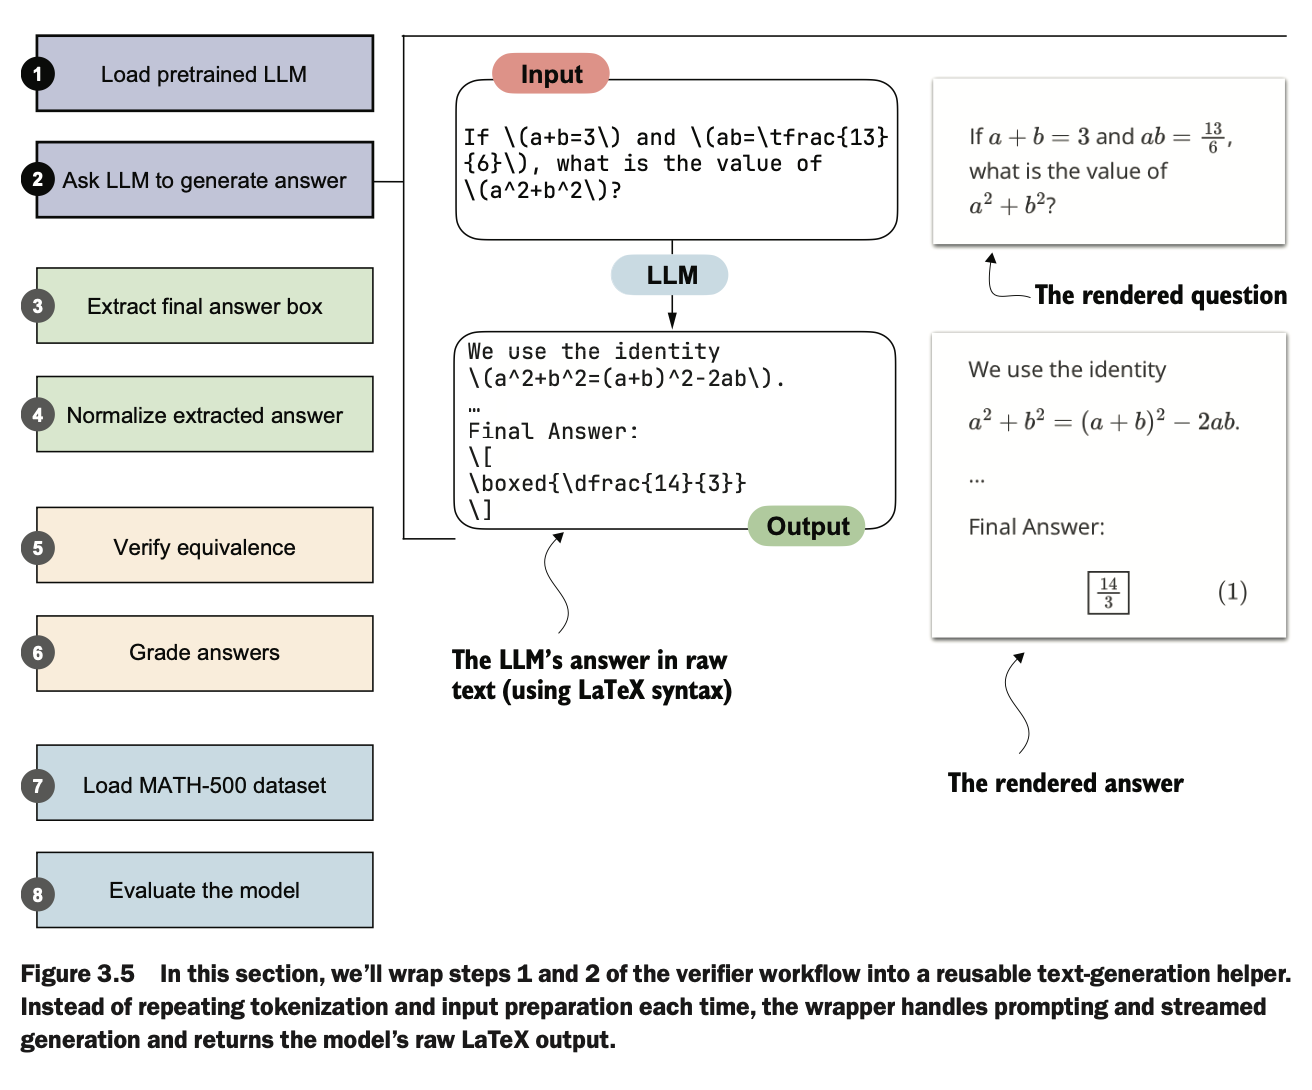


In [13]:
# Listing 3.3 A wrapper for streamed text generation


def generate_text_stream_concat(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens,
    verbose=False,
):
    # Encode prompt text into token IDs and place on device.
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)

    generated_ids = []

    # Stream tokens one by one using cached generation.
    for token in generate_text_basic_stream_cache(
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        # Optionally print tokens as they are generated.
        if verbose:
            print(tokenizer.decode(next_token_id.tolist()), end="", flush=True)

    # Decode all generated IDs into final text string.
    return tokenizer.decode(generated_ids)


skip_portion = False

if not skip_portion:
    generated_text = generate_text_stream_concat(
        model,
        tokenizer,
        prompt,
        device,
        max_new_tokens=2048,
        verbose=True,  # Using False will suppress the live token-by-token printing.
    )

 To find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [14]:
# The answer box we want to extract
model_answer = r"""... some explanation...
**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]
"""

In [15]:
# Listing 3.4 Extracting answer boxes


def get_last_boxed(text):
    # Find the last occurrence of "\boxed"
    boxed_start_idx = text.rfind(r"\boxed")
    if boxed_start_idx == -1:
        return None

    # Get position after "\boxed"
    current_idx = boxed_start_idx + len(r"\boxed")

    # Skip any whitespace after "\boxed"
    while current_idx < len(text) and text[current_idx].isspace():
        current_idx += 1

    # Expect an opening brace "{"
    if current_idx >= len(text) or text[current_idx] != "{":
        return None

    # Parse the braces with nesting
    current_idx += 1
    brace_depth = 1
    content_start_idx = current_idx

    while current_idx < len(text) and brace_depth > 0:
        char = text[current_idx]
        if char == "{":
            brace_depth += 1
        elif char == "}":
            brace_depth -= 1
        current_idx += 1

    # Account for unbalanced braces
    if brace_depth != 0:
        return None

    # Extract content inside the outermost braces
    return text[content_start_idx : current_idx - 1]

In [16]:
extracted_answer = get_last_boxed(model_answer)
print(extracted_answer)

\dfrac{14}{3}


In [17]:
from IPython.display import Math

display(Math(r"\dfrac{14}{3}"))

<IPython.core.display.Math object>

In [ ]:
import re

RE_NUMBER = re.compile(r"-?(?:\d+/\d+|\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)")


def extract_final_candidate(text, fallback="number_then_full"):
    # Default return value if nothing matches
    result = ""

    if text:
        # Prefer the last boxed expression if present
        boxed = get_last_boxed(text.strip())
        if boxed:
            result = boxed.strip().strip("$ ")

        # If no boxed expression, try fallback
        elif fallback in ("number_then_full", "number_only"):
            m = RE_NUMBER.findall(text)
            if m:
                # Use last number
                result = m[-1]
            elif fallback == "number_then_full":
                # Else return full text if no number found
                result = text
    return result


""" 
This extract_final_candidate function provides fallback settings in case no boxed
answer is found, as follows:
  "number_then_full" (the default): Pick the last simple number; otherwise, pick
   the whole text.
  "number_only": Pick the last simple number; otherwise, return an empty string ""
  "none": Extract only the boxed content; otherwise, return an empty string ""
"""

In [21]:
print(extract_final_candidate(model_answer))

print(extract_final_candidate(r"\boxed{ 14/3. }"))

print(extract_final_candidate("abc < > 14/3 abc"))

\dfrac{14}{3}
14/3.
14/3


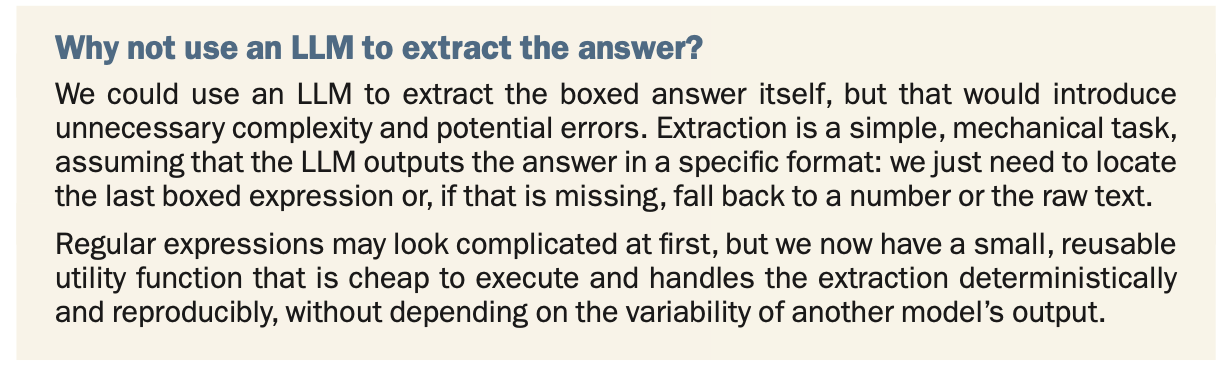


# 3.5 Normalizing the extracted answer

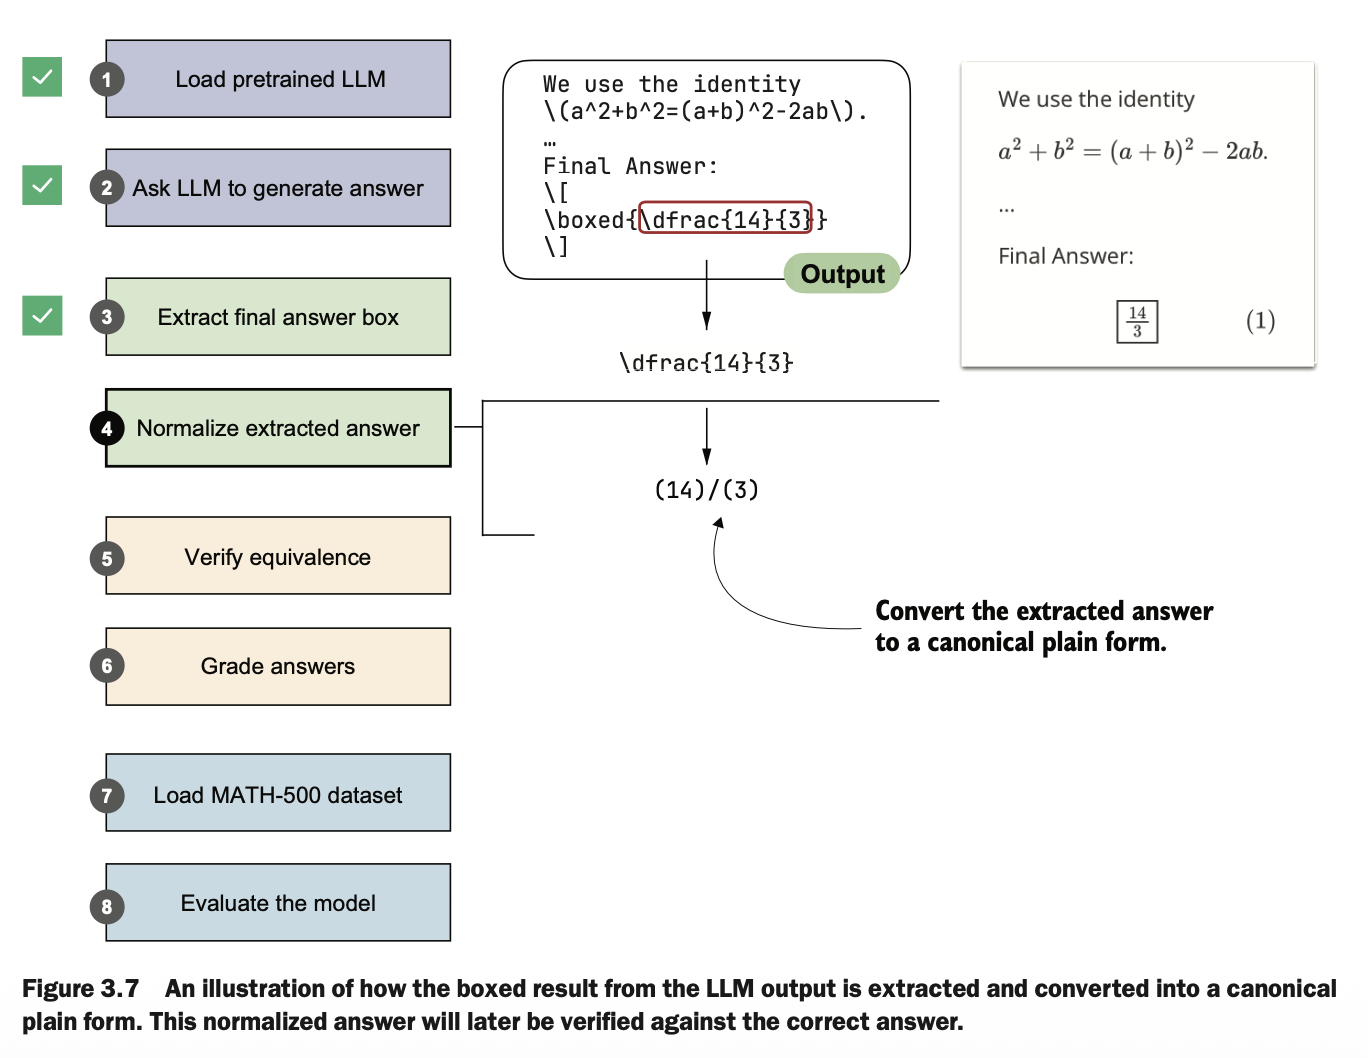


In [22]:
LATEX_FIXES = [  # Latex formatting to be replaced
    (r"\\left\s*", ""),
    (r"\\right\s*", ""),
    (r"\\,|\\!|\\;|\\:", ""),
    (r"\\cdot", "*"),
    (r"\u00B7|\u00D7", "*"),
    (r"\\\^\\circ", ""),
    (r"\\dfrac", r"\\frac"),
    (r"\\tfrac", r"\\frac"),
    (r"°", ""),
]

RE_SPECIAL = re.compile(r"<\|[^>]+?\|>")  # strip chat special tokens like <|assistant|>


def normalize_text(text):
    if not text:
        return ""
    text = RE_SPECIAL.sub("", text).strip()
    SUPERSCRIPT_MAP = {
        "⁰": "0",
        "¹": "1",
        "²": "2",
        "³": "3",
        "⁴": "4",
        "⁵": "5",
        "⁶": "6",
        "⁷": "7",
        "⁸": "8",
        "⁹": "9",
        "⁺": "+",
        "⁻": "-",
        "⁽": "(",
        "⁾": ")",
    }

    # Strip leading multiple-choice labels
    # E.g., like "c. 3" -> 3, or "b: 2" -> 2
    match = re.match(r"^[A-Za-z]\s*[.:]\s*(.+)$", text)
    if match:
        text = match.group(1)

    # Remove angle-degree markers
    text = re.sub(r"\^\s*\{\s*\\circ\s*\}", "", text)  # ^{\circ}
    text = re.sub(r"\^\s*\\circ", "", text)  # ^\circ
    text = text.replace("°", "")  # Unicode degree

    # unwrap \text{...} if the whole string is wrapped
    match = re.match(r"^\\text\{(?P<x>.+?)\}$", text)
    if match:
        text = match.group("x")

    # strip inline/display math wrappers \( \) \[ \]
    text = re.sub(r"\\\(|\\\)|\\\[|\\\]", "", text)

    # light LaTeX canonicalization
    for pat, rep in LATEX_FIXES:
        text = re.sub(pat, rep, text)

    def convert_superscripts(s, base=None):
        converted = "".join(
            SUPERSCRIPT_MAP[ch] if ch in SUPERSCRIPT_MAP else ch for ch in s
        )
        if base is None:
            return converted
        return f"{base}**{converted}"

    # convert unicode superscripts into exponent form (e.g., 2² -> 2**2)m
    text = re.sub(
        r"([0-9A-Za-z\)\]\}])([⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻]+)",
        lambda m: convert_superscripts(m.group(2), base=m.group(1)),
        text,
    )
    text = convert_superscripts(text)

    # numbers/roots
    text = text.replace("\\%", "%").replace("$", "").replace("%", "")
    text = re.sub(
        r"\\sqrt\s*\{([^}]*)\}",
        lambda match: f"sqrt({match.group(1)})",
        text,
    )
    text = re.sub(
        r"\\sqrt\s+([^\\\s{}]+)",
        lambda match: f"sqrt({match.group(1)})",
        text,
    )

    # fractions
    text = re.sub(
        r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}",
        lambda match: f"({match.group(1)})/({match.group(2)})",
        text,
    )
    text = re.sub(
        r"\\frac\s+([^\s{}]+)\s+([^\s{}]+)",
        lambda match: f"({match.group(1)})/({match.group(2)})",
        text,
    )

    # exponent and mixed numbers
    text = text.replace("^", "**")
    text = re.sub(
        r"(?<=\d)\s+(\d+/\d+)",
        lambda match: "+" + match.group(1),
        text,
    )

    # 1,234 -> 1234
    text = re.sub(
        r"(?<=\d),(?=\d\d\d(\D|$))",
        "",
        text,
    )

    return text.replace("{", "").replace("}", "").strip().lower()

In [24]:
print(normalize_text(extract_final_candidate(model_answer)))

print(normalize_text(r"\text{\[\frac{14}{3}\]}"))

(14)/(3)
(14)/(3)


# 3.6 Verifying mathematical equivalence

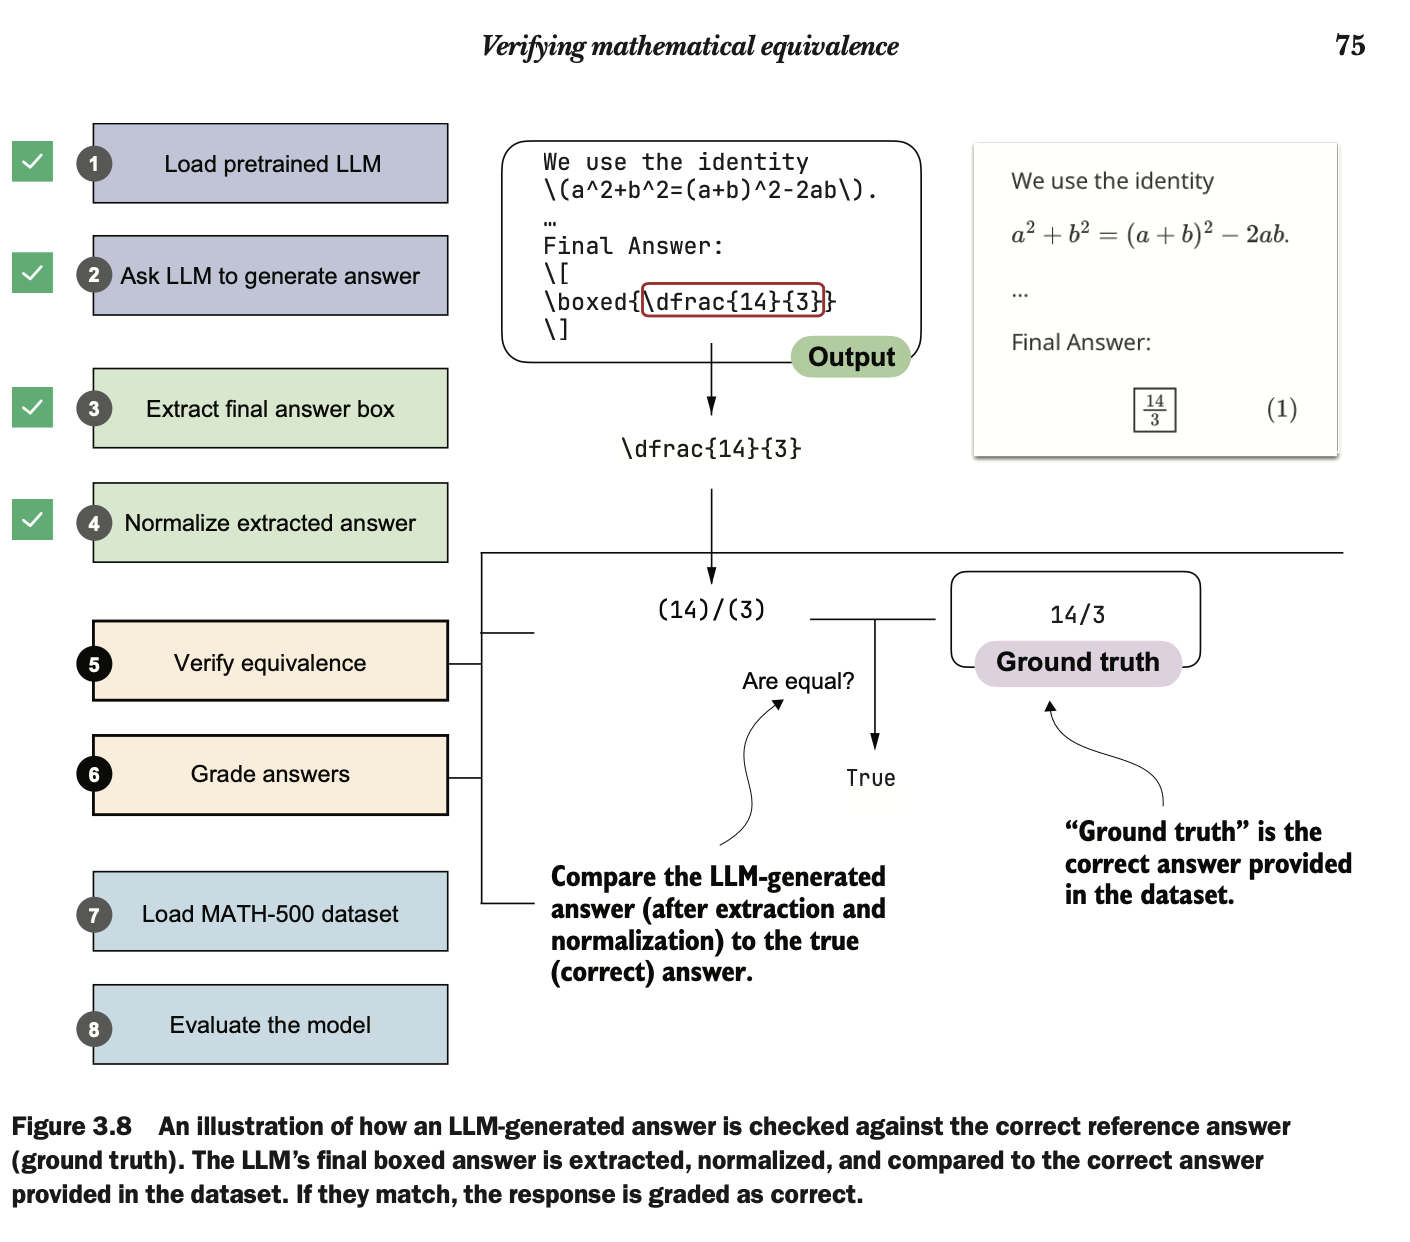


In [ ]:
from sympy.parsing import sympy_parser as spp
from sympy.core.sympify import SympifyError
from tokenize import TokenError
from sympy.polys.polyerrors import PolynomialError


def sympy_parser(expr):

    # To avoid crashing on long garbage responses
    # that some badly trained models (chapter 6) may emit
    if expr is None or len(expr) > 2000:
        return None
    try:
        return spp.parse_expr(
            expr,
            transformations=(
                # Standard transformations like handling parentheses
                *spp.standard_transformations,
                # Allow omitted multiplication symbols (e.g., "2x" -> 2*x")
                spp.implicit_multiplication_application,
            ),
            # Evaluate during parsing so simple constants simplify (e.g., 2+3 -> 5)
            evaluate=True,
        )
    except (
        SympifyError,
        SyntaxError,
        TypeError,
        AttributeError,
        IndexError,
        TokenError,
        ValueError,
        PolynomialError,
    ):  # type: ignore
        return None

In [27]:
print(sympy_parser(normalize_text(extract_final_candidate(model_answer))))

14/3


In [28]:
print(sympy_parser("28/6"))

14/3


In [29]:
from sympy import simplify


def equality_check(expr_gtruth, expr_pred):
    # First, check if the two expressions are exactly the same string
    if expr_gtruth == expr_pred:
        return True

    # Parse both expressions into SymPy objects (returns None if parsing fails)
    gtruth, pred = sympy_parser(expr_gtruth), sympy_parser(expr_pred)

    # If both expressions were parsed successfully, try symbolic comparison
    if gtruth is not None and pred is not None:
        try:
            # If the difference is 0, they are equivalent
            return simplify(gtruth - pred) == 0
        except (SympifyError, TypeError):
            pass

    return False

In [30]:
print(equality_check(normalize_text("13/4."), normalize_text(r"(13)/(4)")))

True


In [31]:
print(equality_check(normalize_text("0.5"), normalize_text(r"(1)/(2)")))

True


In [32]:
print(equality_check(normalize_text("14/3"), normalize_text("15/3")))

False


In [33]:
print(equality_check(normalize_text("(14/3, 2/3)"), normalize_text("(14/3, 4/6)")))

False


# 3.7 Grading answers

- Now we’ll build on the previous section’s mathematical equality-checking function to
  implement a robust grading function that can also handle tuple-like expressions, such
  as correctly comparing "(14/3, 2/3)" and "(14/3, 4/6)".

- First, we’ll implement a Python helper function that splits such tuple-like expressions
  into individual subparts.


In [34]:
# Listing 3.9 A helper function to split tuple-like expressions


def split_into_parts(text):
    result = [text]

    if text:
        # Check if text looks like a tuple or list, e.g. "(a, b)" or "[a, b]"
        if (
            len(text) >= 2
            and text[0] in "(["
            and text[-1] in ")]"
            and "," in text[1:-1]
        ):
            # Split on commas inside brackets and strip whitespace
            items = [p.strip() for p in text[1:-1].split(",")]
            if all(items):
                result = items
    else:
        # If text is empty, return an empty list
        result = []

    return result

In [35]:
split_into_parts(normalize_text(r"(14/3, 2/3)"))

['14/3', '2/3']